# Medical Insurance Cost Analysis

## Objective
This project explores a real-world medical insurance dataset to identify the main factors that influence insurance charges. The analysis focuses on understanding patterns in the data, generating visual insights, and building a foundation for predictive modelling.

## 1. Data Loading and Initial Exploration

The dataset is loaded and examined to understand its structure, data types, and overall quality before performing deeper analysis.

In [1]:
import pandas as pd

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Dataset Overview

The dataset contains 1,338 records and 7 variables, including both numerical and categorical features.

There are no missing values, indicating that the dataset is clean and suitable for analysis.

### Key Observations

- The average age is approximately 39 years
- The average BMI is around 31, indicating a generally overweight population
- The average number of children is around 1
- The average insurance cost is 13270
- Insurance charges vary significantly, ranging from around 1,100 to over 63,000

This large variation suggests that certain variables have a strong influence on insurance costs and should be explored further.

## 2. Age vs Insurance Charges

This section explores the relationship between age and insurance costs.

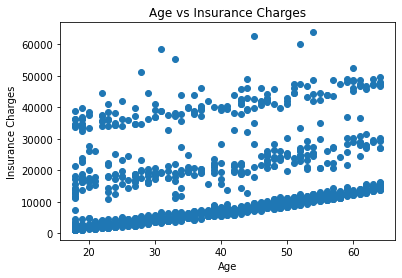

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.title('Age vs Insurance Charges')
plt.show()

### Insights

A scatter plot was used in this analysis because we are examining the relationship between two continuous variables: age and insurance charges.

Since both variables are numerical, a scatter plot provides a clear and effective way to visualise how one variable changes in relation to the other, helping to identify trends, patterns, and clusters in the data.

The scatter plot shows a clear positive relationship between age and insurance charges. As age increases, insurance costs generally rise.

However, the data appears to form distinct bands rather than a single smooth trend. This suggests that another variable, such as smoking status, may also be influencing insurance charges.

This indicates that while age is an important factor, it is not the only driver of insurance costs.

## 3. Impact of Smoking on Insurance Charges

This section investigates whether smoking status explains the variation observed in insurance charges.

In [5]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

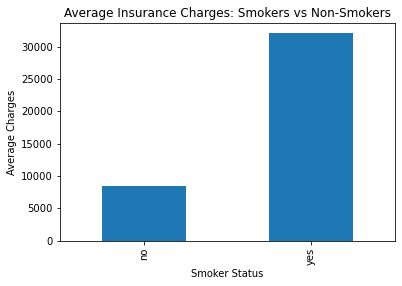

In [6]:
df.groupby('smoker')['charges'].mean().plot(kind='bar')
plt.title('Average Insurance Charges: Smokers vs Non-Smokers')
plt.ylabel('Average Charges')
plt.xlabel('Smoker Status')
plt.show()

### Insights

A bar chart is used in this analysis because we are comparing the average insurance charges between two categorical groups: smokers and non-smokers.

Since smoking status is a categorical variable and charges are numerical, a bar chart provides a clear and effective way to visualise the difference in average values between these groups.

The analysis reveals a significant difference in insurance charges between smokers and non-smokers.

Smokers incur substantially higher medical costs, indicating that smoking is one of the strongest predictors of insurance charges.

This finding explains the distinct bands observed in the age vs charges plot, as smoking status creates clear separation in the data.

## 4. BMI vs Insurance Charges

This section explores the relationship between Body Mass Index (BMI) and insurance costs.

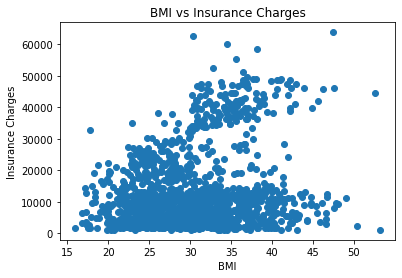

In [7]:
plt.scatter(df['bmi'], df['charges'])
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('BMI vs Insurance Charges')
plt.show()

.
### Insights

A scatter plot was used in this analysis because we are examining the relationship between two continuous variables: BMI and insurance charges.

Since both variables are numerical, a scatter plot provides a clear and effective way to visualise how one variable changes in relation to the other, helping to identify trends, patterns, and clusters in the data

The scatter plot shows a weaker relationship between BMI and insurance charges compared to age.

While higher BMI values are sometimes associated with increased charges, the overall pattern is less clear and more dispersed.

This suggests that BMI alone is not a strong predictor of insurance costs, but it may still contribute when combined with other factors such as smoking status.

## 5. Correlation Analysis

This section examines the relationships between numerical variables in the dataset to identify which factors are most strongly associated with insurance charges.

In [8]:
df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


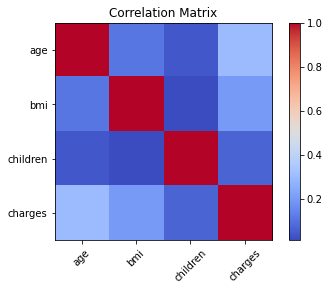

In [9]:
import matplotlib.pyplot as plt

plt.imshow(df.corr(), cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(df.corr().columns)), df.corr().columns, rotation=45)
plt.yticks(range(len(df.corr().columns)), df.corr().columns)
plt.title('Correlation Matrix')
plt.show()

In [10]:
corr_matrix = df.corr()
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


### Why a Correlation Matrix Was Used

A correlation matrix was used to evaluate the strength and direction of relationships between multiple numerical variables simultaneously.

This method allows us to quickly identify which factors have the strongest association with insurance charges and compare their relative importance.

---

### Insights

Pearson correlation analysis shows age has the strongest numerical association with insurance charges (r = 0.299), indicating a weak to moderate positive linear relationship. This suggests charges tend to increase with age, although age alone is not a strong predictor of costs.

BMI shows a weaker positive correlation with insurance charges (r = 0.198), supporting earlier visual analysis that BMI may contribute to costs but is not a strong standalone driver.

The number of children has a near-zero correlation with charges (r = 0.068), indicating minimal linear relationship and little predictive influence.

Smoking status is not represented in the Pearson correlation matrix because it is a categorical variable rather than a continuous numerical variable. However, earlier analysis showed smoking to be a major driver of higher insurance costs.

Overall, the Pearson coefficients suggest insurance charges are influenced by multiple factors, with age showing the strongest numerical relationship among continuous variables, while smoking appears to be the strongest overall predictor.